# Project CV2: Robust Head Pose Estimation Under Facial Occlusions

Work by Antonio Vila Leis and Enric Baixauli Casañ

## Introduction

This project addresses the challenge of accurately estimating head posture in the presence of facial occlusions, such as masks and sunglasses.

TODO explicar todo

In [1]:
import os
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
import sys
from dataset import LP300W, I2HeadDataset
import utils
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import time
from models.utils_hpe import compute_euler_angles_from_rotation_matrices
import cv2
import torch._dynamo
torch._dynamo.config.suppress_errors = True

C:\Users\enric\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\face_alignment\api.py:130: UserWarning: Compiling face alignment model (one-time cost). Subsequent runs will be faster.
  warnings.warn(
torch.compile failed (backend='inductor' raised:
RuntimeError: Cannot find a working triton installation. Either the package is not installed or it is too old. More information on installing Triton can be found at https://github.com/openai/triton

Set TORCH_LOGS="+dynamo" and TORCHDYNAMO_VERBOSE=1 for more information


You can suppress this exception and fall back to eager by setting:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True
), using eager mode


In [2]:
utils.set_global_seed(123)

if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
device = torch.device(device_name)
print(f"Code runs in {device}")

Code runs in cuda


## 1. Data Loading

In [3]:
import os
import random
from torch.utils.data import DataLoader
import torchvision.transforms as T

RAW_DATASET_DIR = "./dataset/test/raw"
BATCH_SIZE = 32

transforms_pipeline = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

subjects_dict = {}

# Parse baseline references from the raw directory
for file in os.listdir(RAW_DATASET_DIR):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        filename_no_ext = os.path.splitext(file)[0]
        
        # Extract subject prefix (e.g., pulls 'p01' from 'p01_image_01_raw' or 'p01_image_01')
        subject_id = filename_no_ext.split("_")[0] 
        
        full_path = os.path.join(RAW_DATASET_DIR, file)
        
        if subject_id not in subjects_dict:
            subjects_dict[subject_id] = []
        subjects_dict[subject_id].append(full_path)

unique_subjects = sorted(list(subjects_dict.keys()))
print(f"Total number of people found: {len(unique_subjects)}")

# Subject-level Split (10 Train / 1 Val / 1 Test)
random.seed(123)
random.shuffle(unique_subjects)

train_subj = unique_subjects[:9]
val_subj   = [unique_subjects[9]]
test_subj  = unique_subjects[10:]

print(f"Split people -> Train: {train_subj} | Val: {val_subj} | Test: {test_subj}")

# Gather lists of paths
train_paths = []
for subj in train_subj:
    train_paths.extend(subjects_dict[subj])

val_paths = []
for subj in val_subj:
    val_paths.extend(subjects_dict[subj])

test_paths = []
for subj in test_subj:
    test_paths.extend(subjects_dict[subj])

print(f"Split images -> Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# Instantiate Datasets
train_dataset = I2HeadDataset(image_paths_or_dir=train_paths, transform=transforms_pipeline, occlusion_mode="random")
val_dataset   = I2HeadDataset(image_paths_or_dir=val_paths, transform=transforms_pipeline, occlusion_mode="random")

# Define the 4 isolated evaluation tracks matching the test subject
test_raw     = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="raw")
test_mask    = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="mask")
test_glasses = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="glasses")
test_both    = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="both")

# Construct DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

raw_loader     = DataLoader(test_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
mask_loader    = DataLoader(test_mask, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
glasses_loader = DataLoader(test_glasses, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
both_loader    = DataLoader(test_both, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print("DataLoaders built successfully!")

Total number of people found: 12
Split people -> Train: ['p08', 'p06', 'p10', 'p03', 'p04', 'p09', 'p12', 'p11', 'p07'] | Val: ['p02'] | Test: ['p05', 'p01']
Split images -> Train: 738 | Val: 82 | Test: 164
DataLoaders built successfully!


In [4]:
sys.path.append("./models")

from token_hpe import TokenHPE

model = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

state_dict = checkpoint["model_state_dict"]

model.load_state_dict(state_dict, strict=True)

model = model.to(device)

==> Add Sine PositionEmbedding~


C:\Users\enric\AppData\Local\Temp\ipykernel_8740\1715322118.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-ly

In [5]:
model.eval()

print("\n-> Test 1/4: RAW")
mae_r, rmse_r, nrmse_r = utils.evaluate_metrics(model, raw_loader, device)

print("\n-> Test 2/4: MASK")
mae_m, rmse_m, nrmse_m = utils.evaluate_metrics(model, mask_loader, device)

print("\n-> Test 3/4: GLASSES")
mae_g, rmse_g, nrmse_g = utils.evaluate_metrics(model, glasses_loader, device)

print("\n-> Test 4/4: BOTH")
mae_b, rmse_b, nrmse_b = utils.evaluate_metrics(model, both_loader, device)

def print_results(test_name, mae, rmse, nrmse):
    print(f"\n{test_name}")
    print(f"  MAE -> Yaw: {mae['yaw']} | Pitch: {mae['pitch']} | Roll: {mae['roll']} | Total: {mae['total']}")
    print(f"  RMSE -> Yaw: {rmse['yaw']} | Pitch: {rmse['pitch']} | Roll: {rmse['roll']} | Total: {rmse['total']}")
    print(f"  NRMSE -> Yaw: {nrmse['yaw']} | Pitch: {nrmse['pitch']} | Roll: {nrmse['roll']} | Total: {nrmse['total']}")

print_results("Test RAW:", mae_r, rmse_r, nrmse_r)
print_results("Test MASK:", mae_m, rmse_m, nrmse_m)
print_results("Test GLASSES:", mae_g, rmse_g, nrmse_g)
print_results("Test BOTH:", mae_b, rmse_b, nrmse_b)


-> Test 1/4: RAW


Evaluating: 100%|██████████| 6/6 [00:02<00:00,  2.96it/s]



-> Test 2/4: MASK


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.34it/s]



-> Test 3/4: GLASSES


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.28it/s]



-> Test 4/4: BOTH


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.32it/s]


Test RAW:
  MAE -> Yaw: 0.12259228527545929 | Pitch: 0.1570236086845398 | Roll: 0.1368132382631302 | Total: 0.1388096958398819
  RMSE -> Yaw: 0.15527920424938202 | Pitch: 0.20764875411987305 | Roll: 0.15655317902565002 | Total: 0.1731603890657425
  NRMSE -> Yaw: 0.2784444987773895 | Pitch: 1.370741367340088 | Roll: 0.38516727089881897 | Total: 0.6781177520751953

Test MASK:
  MAE -> Yaw: 0.3934626281261444 | Pitch: 0.15674397349357605 | Roll: 0.08211416006088257 | Total: 0.21077358722686768
  RMSE -> Yaw: 0.4482223391532898 | Pitch: 0.2048194706439972 | Roll: 0.10380588471889496 | Total: 0.25228258967399597
  NRMSE -> Yaw: 0.8037460446357727 | Pitch: 1.352064609527588 | Roll: 0.25539326667785645 | Total: 0.8037346005439758

Test GLASSES:
  MAE -> Yaw: 0.17473526298999786 | Pitch: 0.14715471863746643 | Roll: 0.14066772162914276 | Total: 0.15418590605258942
  RMSE -> Yaw: 0.20160265266895294 | Pitch: 0.18720123171806335 | Roll: 0.1644745022058487 | Total: 0.18442612886428833
  NRMSE -> 

# Fine-Tunning

## Total Fine-Tunning

In [10]:
criterion = nn.L1Loss()

optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

epochs = 5
best_val_loss = float('inf')

In [11]:
def train_model(epochs=epochs, model=model, name = "base", train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device):
    global best_val_loss
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        start_time = time.time()

        # Training
        model.train()
        running_train_loss = 0.0
    
        for imgs, poses in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            imgs, poses = imgs.to(device), poses.to(device)
            
            optimizer.zero_grad()
            
            predictions = model(imgs)
            
            if isinstance(predictions, (tuple, list)):
                pred_mat = predictions[0]
                pred_angles = compute_euler_angles_from_rotation_matrices(pred_mat, use_gpu=True)
                pred_angles = pred_angles.to(device)
            else:
                pred_angles = predictions
                
            loss = criterion(pred_angles, poses)
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * imgs.size(0)
            
        epoch_train_loss = running_train_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for imgs, poses in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                imgs, poses = imgs.to(device), poses.to(device)
                
                predictions = model(imgs)
                
                if isinstance(predictions, (tuple, list)):
                    pred_mat = predictions[0]
                    pred_angles = compute_euler_angles_from_rotation_matrices(pred_mat, use_gpu=True)
                    pred_angles = pred_angles.to(device)
                else:
                    pred_angles = predictions
                    
                loss = criterion(pred_angles, poses)
                running_val_loss += loss.item() * imgs.size(0)
                
        epoch_val_loss = running_val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)
        
        scheduler.step(epoch_val_loss)
        
        epoch_time = time.time() - start_time
        
        print(f"\nEpoch {epoch+1}/{epochs} completed in {epoch_time:.0f}s")
        print(f"Train Loss (MAE radians): {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            save_path = "./weights/TokenHPE_Finetuned_" + name + ".pth"
            torch.save(model.state_dict(), save_path)
            print("Best model updated")
        else:
            print("\n")
    return train_losses, val_losses

In [16]:
l_trainC,l_valC = train_model(name="Complete", epochs=epochs, model=model, optimizer=optimizer, scheduler=scheduler)

Epoch 1/5 [Val]: 100%|██████████| 3/3 [00:37<00:00, 12.59s/it]



Epoch 1/5 completed in 141s
Train Loss (MAE radians): 0.1078 | Val Loss: 0.1055
Best model updated


Epoch 2/5 [Val]: 100%|██████████| 3/3 [00:35<00:00, 11.91s/it]



Epoch 2/5 completed in 121s
Train Loss (MAE radians): 0.0787 | Val Loss: 0.1386




Epoch 3/5 [Val]: 100%|██████████| 3/3 [00:35<00:00, 12.00s/it]



Epoch 3/5 completed in 124s
Train Loss (MAE radians): 0.0478 | Val Loss: 0.1386




Epoch 4/5 [Val]: 100%|██████████| 3/3 [00:36<00:00, 12.02s/it]



Epoch 4/5 completed in 124s
Train Loss (MAE radians): 0.0395 | Val Loss: 0.1399




Epoch 5/5 [Val]: 100%|██████████| 3/3 [00:36<00:00, 12.18s/it]


Epoch 5/5 completed in 125s
Train Loss (MAE radians): 0.0279 | Val Loss: 0.1199




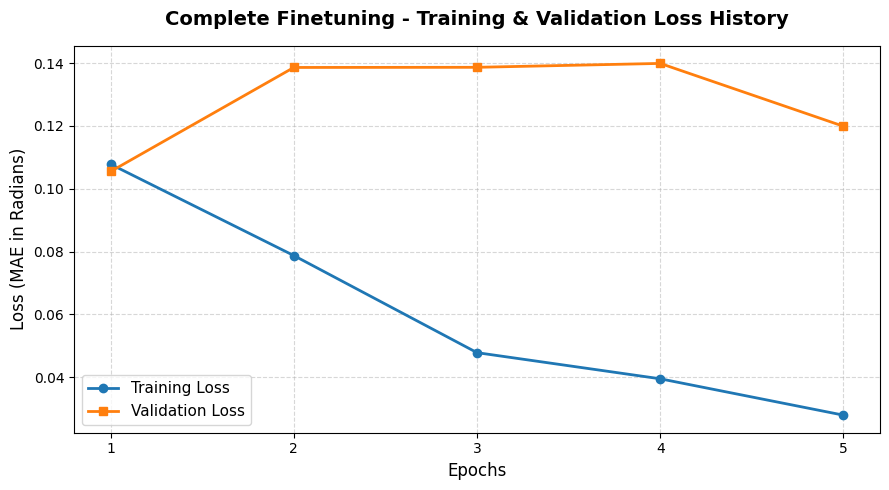

In [17]:
utils.plot_training_history(l_trainC, l_valC, model_name="Complete Finetuning")

In [6]:
sys.path.append("./models")

from token_hpe import TokenHPE

model_C = TokenHPE(depth=3)
checkpoint_path = "./weights/TokenHPE_Finetuned_Complete.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

state_dict = checkpoint.get("model_state_dict", checkpoint)
model_C.load_state_dict(state_dict, strict=True)

model_C = model_C.to(device)
model_C.eval()

print("\n-> Test 1/4: RAW")
mae_r, rmse_r, r2_r = utils.evaluate_metrics(model_C, raw_loader, device)

print("\n-> Test 2/4: MASK")
mae_m, rmse_m, r2_m = utils.evaluate_metrics(model_C, mask_loader, device)

print("\n-> Test 3/4: GLASSES")
mae_g, rmse_g, r2_g = utils.evaluate_metrics(model_C, glasses_loader, device)

print("\n-> Test 4/4: BOTH")
mae_b, rmse_b, r2_b = utils.evaluate_metrics(model_C, both_loader, device)

def print_results(test_name, mae, rmse, r2):
    print(f"\n{test_name}")
    print(f"  MAE -> Yaw: {mae['yaw']} | Pitch: {mae['pitch']} | Roll: {mae['roll']} | Total: {mae['total']}")
    print(f"  RMSE -> Yaw: {rmse['yaw']} | Pitch: {rmse['pitch']} | Roll: {rmse['roll']} | Total: {rmse['total']}")
    print(f"  R² -> Yaw: {r2['yaw']} | Pitch: {r2['pitch']} | Roll: {r2['roll']} | Total: {r2['total']}")

print_results("Test RAW:", mae_r, rmse_r, r2_r)
print_results("Test MASK:", mae_m, rmse_m, r2_m)
print_results("Test GLASSES:", mae_g, rmse_g, r2_g)
print_results("Test BOTH:", mae_b, rmse_b, r2_b)


==> Add Sine PositionEmbedding~


/tmp/ipykernel_22369/1375103960.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")



-> Test 1/4: RAW


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.06it/s]



-> Test 2/4: MASK


...


-> Test 3/4: GLASSES


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.31it/s]



-> Test 4/4: BOTH


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.32it/s]


Test RAW:
  MAE -> Yaw: 0.1750580370426178 | Pitch: 0.027453340590000153 | Roll: 0.08902306854724884 | Total: 0.0971781387925148
  RMSE -> Yaw: 0.21441468596458435 | Pitch: 0.03340359404683113 | Roll: 0.10928547382354736 | Total: 0.11903458833694458
  R² -> Yaw: 0.3844854235649109 | Pitch: 0.2205054759979248 | Roll: 0.2688747048377991 | Total: 0.2912885248661041

Test MASK:
  MAE -> Yaw: 0.17263053357601166 | Pitch: 0.0256873220205307 | Roll: 0.08785606175661087 | Total: 0.09539130330085754
  RMSE -> Yaw: 0.2111346274614334 | Pitch: 0.03138992562890053 | Roll: 0.10799624025821686 | Total: 0.11684026569128036
  R² -> Yaw: 0.37860366702079773 | Pitch: 0.20721274614334106 | Roll: 0.2657027840614319 | Total: 0.28383973240852356

Test GLASSES:
  MAE -> Yaw: 0.1722838282585144 | Pitch: 0.02763570472598076 | Roll: 0.08915305882692337 | Total: 0.09635753184556961
  RMSE -> Yaw: 0.21121805906295776 | Pitch: 0.033491961658000946 | Roll: 0.10899009555578232 | Total: 0.11790004372596741
  R² -> Y

## LoRA

In [5]:
sys.path.append("./models")

from token_hpe import TokenHPE

model_lora = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

state_dict = checkpoint["model_state_dict"]

model_lora.load_state_dict(state_dict, strict=True)

model_lora = model_lora.to(device)

==> Add Sine PositionEmbedding~


C:\Users\enric\AppData\Local\Temp\ipykernel_8740\2471208752.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-ly

In [6]:
for name, m in model_lora.feature_extractor.named_modules():
    if 'qkv' in name or 'attn' in name or 'proj' in name:
        print(name)

patch_embed.proj
blocks.0.attn
blocks.0.attn.qkv
blocks.0.attn.attn_drop
blocks.0.attn.proj
blocks.0.attn.proj_drop
blocks.1.attn
blocks.1.attn.qkv
blocks.1.attn.attn_drop
blocks.1.attn.proj
blocks.1.attn.proj_drop
blocks.2.attn
blocks.2.attn.qkv
blocks.2.attn.attn_drop
blocks.2.attn.proj
blocks.2.attn.proj_drop
blocks.3.attn
blocks.3.attn.qkv
blocks.3.attn.attn_drop
blocks.3.attn.proj
blocks.3.attn.proj_drop
blocks.4.attn
blocks.4.attn.qkv
blocks.4.attn.attn_drop
blocks.4.attn.proj
blocks.4.attn.proj_drop
blocks.5.attn
blocks.5.attn.qkv
blocks.5.attn.attn_drop
blocks.5.attn.proj
blocks.5.attn.proj_drop
blocks.6.attn
blocks.6.attn.qkv
blocks.6.attn.attn_drop
blocks.6.attn.proj
blocks.6.attn.proj_drop
blocks.7.attn
blocks.7.attn.qkv
blocks.7.attn.attn_drop
blocks.7.attn.proj
blocks.7.attn.proj_drop
blocks.8.attn
blocks.8.attn.qkv
blocks.8.attn.attn_drop
blocks.8.attn.proj
blocks.8.attn.proj_drop
blocks.9.attn
blocks.9.attn.qkv
blocks.9.attn.attn_drop
blocks.9.attn.proj
blocks.9.attn.pro

In [7]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=16, 
    lora_alpha=32, 
    target_modules=["qkv"], # Targets the self-attention projections in the ViT blocks
    lora_dropout=0.1,
    bias="none"
)

model_lora.feature_extractor = get_peft_model(model_lora.feature_extractor, config)
model_lora = model_lora.to(device)

In [8]:
# We completely freeze all the parameters of the base model
for param in model_lora.parameters():
    param.requires_grad = False

# We only unfreeze the parameters that contain "lora" and the downstream task modules
for name, param in model_lora.named_parameters():
    if "lora" in name or "Ori_blocks" in name or "mlp_head" in name:
        param.requires_grad = True

# Here we can see how many parameters will actually be trained
trainable_params = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_lora.parameters())
print(f"Trainable Parameters: {trainable_params:,} out of {total_params:,} "
      f"({trainable_params/total_params:.2%})")

Trainable Parameters: 1,231,636 out of 87,034,906 (1.42%)


In [12]:
criterion = nn.L1Loss()

optimizer_lora = optim.AdamW(
    filter(lambda p: p.requires_grad, model_lora.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lora, mode='min', patience=3, factor=0.5, verbose=True
)

best_val_loss = float('inf')
epochs = 10
best_val_loss = float('inf')
l_trainL, l_valL = train_model(epochs=epochs, model=model_lora, optimizer=optimizer_lora, scheduler=scheduler, name="LoRA")

Epoch 1/10 [Val]: 100%|██████████| 3/3 [00:31<00:00, 10.36s/it]



Epoch 1/10 completed in 73s
Train Loss (MAE radians): 0.0902 | Val Loss: 0.1086
Best model updated


Epoch 2/10 [Val]: 100%|██████████| 3/3 [00:27<00:00,  9.27s/it]



Epoch 2/10 completed in 67s
Train Loss (MAE radians): 0.0692 | Val Loss: 0.1272




Epoch 3/10 [Val]: 100%|██████████| 3/3 [00:28<00:00,  9.51s/it]


...


Epoch 8/10 completed in 67s
Train Loss (MAE radians): 0.0379 | Val Loss: 0.1208




Epoch 9/10 [Val]: 100%|██████████| 3/3 [00:28<00:00,  9.54s/it]



Epoch 9/10 completed in 67s
Train Loss (MAE radians): 0.0348 | Val Loss: 0.1172




Epoch 10/10 [Val]: 100%|██████████| 3/3 [00:28<00:00,  9.45s/it]


Epoch 10/10 completed in 68s
Train Loss (MAE radians): 0.0317 | Val Loss: 0.1146




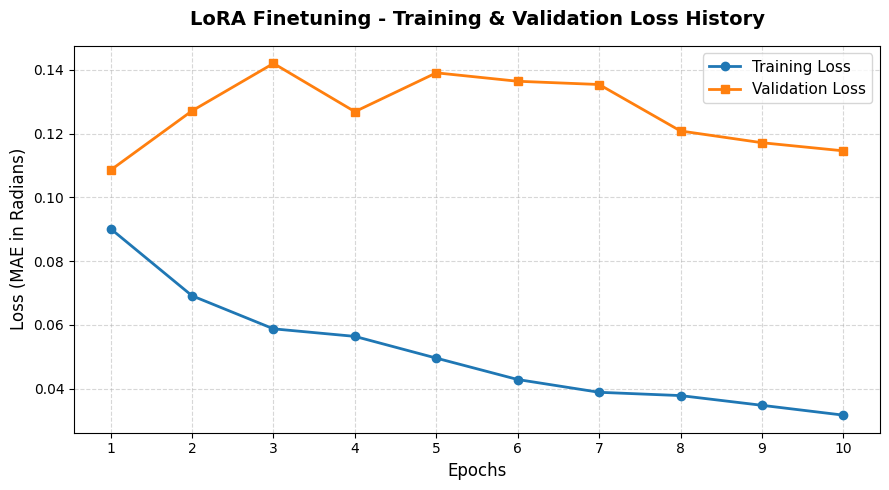

In [13]:
utils.plot_training_history(l_trainL, l_valL, model_name="LoRA Finetuning")

In [14]:
model_lora.eval()

print("\n-> Test 1/4: RAW")
mae_r, rmse_r, r2_r = utils.evaluate_metrics(model_lora, raw_loader, device)

print("\n-> Test 2/4: MASK")
mae_m, rmse_m, r2_m = utils.evaluate_metrics(model_lora, mask_loader, device)

print("\n-> Test 3/4: GLASSES")
mae_g, rmse_g, r2_g = utils.evaluate_metrics(model_lora, glasses_loader, device)

print("\n-> Test 4/4: BOTH")
mae_b, rmse_b, r2_b = utils.evaluate_metrics(model_lora, both_loader, device)

def print_results(test_name, mae, rmse, r2):
    print(f"\n{test_name}")
    print(f"  MAE -> Yaw: {mae['yaw']} | Pitch: {mae['pitch']} | Roll: {mae['roll']} | Total: {mae['total']}")
    print(f"  RMSE -> Yaw: {rmse['yaw']} | Pitch: {rmse['pitch']} | Roll: {rmse['roll']} | Total: {rmse['total']}")
    print(f"  R² -> Yaw: {r2['yaw']} | Pitch: {r2['pitch']} | Roll: {r2['roll']} | Total: {r2['total']}")

print_results("Test RAW:", mae_r, rmse_r, r2_r)
print_results("Test MASK:", mae_m, rmse_m, r2_m)
print_results("Test GLASSES:", mae_g, rmse_g, r2_g)
print_results("Test BOTH:", mae_b, rmse_b, r2_b)


-> Test 1/4: RAW


Evaluating: 100%|██████████| 6/6 [00:29<00:00,  4.88s/it]



-> Test 2/4: MASK


Evaluating: 100%|██████████| 6/6 [00:29<00:00,  4.84s/it]



-> Test 3/4: GLASSES


Evaluating: 100%|██████████| 6/6 [00:29<00:00,  4.86s/it]



-> Test 4/4: BOTH


Evaluating: 100%|██████████| 6/6 [00:28<00:00,  4.77s/it]


Test RAW:
  MAE -> Yaw: 0.13724708557128906 | Pitch: 0.06999862939119339 | Roll: 0.08296426385641098 | Total: 0.09673666208982468
  RMSE -> Yaw: 0.17222923040390015 | Pitch: 0.0831989049911499 | Roll: 0.10611246526241302 | Total: 0.12051353603601456
  R² -> Yaw: 0.3088390529155731 | Pitch: 0.5492168068885803 | Roll: 0.2610681354999542 | Total: 0.3730413019657135

Test MASK:
  MAE -> Yaw: 0.18774935603141785 | Pitch: 0.08377358317375183 | Roll: 0.10897228121757507 | Total: 0.12683174014091492
  RMSE -> Yaw: 0.22702261805534363 | Pitch: 0.09466183185577393 | Roll: 0.12751173973083496 | Total: 0.1497320681810379
  R² -> Yaw: 0.4070937931537628 | Pitch: 0.6248864531517029 | Roll: 0.31371670961380005 | Total: 0.44856563210487366

Test GLASSES:
  MAE -> Yaw: 0.12404234707355499 | Pitch: 0.0594983845949173 | Roll: 0.09687181562185287 | Total: 0.09347084909677505
  RMSE -> Yaw: 0.1537213921546936 | Pitch: 0.07050073146820068 | Roll: 0.12359333038330078 | Total: 0.11593848466873169
  R² -> Yaw

In [15]:
sys.path.append("./models")

from token_hpe import TokenHPE

model_C = TokenHPE(depth=3)
checkpoint_path = "./weights/TokenHPE_Finetuned_Complete.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

state_dict = checkpoint.get("model_state_dict", checkpoint)
model_C.load_state_dict(state_dict, strict=True)

model_C = model_C.to(device)

==> Add Sine PositionEmbedding~


C:\Users\enric\AppData\Local\Temp\ipykernel_8740\3117501556.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")


In [16]:
img_path = "./dataset/test/raw/p01_image_51.png"
img_path2 = "./test_failure/test_failure_background_test.png"
utils.evaluate_paired_images_thpe(img_path, img_path2, model_C)

Error: Modified image path './test_failure/test_failure_background_test.png' does not exist.
